# Anomaly Detection

In [ ]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)

# Load Dataset

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Order Date Function

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [5]:
print(df.shape)

(9800, 18)


# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

# Aggregate Weekly Sales

In [8]:
weekly_sales = (

    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]

    .sum()

    .reset_index()

)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [9]:
weekly_sales.columns = [

    "Week",

    "Weekly Sales"

]

weekly_sales.head()

,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


# Weekly Sales Description

In [10]:
print("Number of Weeks :", len(weekly_sales))

weekly_sales.describe()

Number of Weeks : 209


,Week,Weekly Sales
count,209,209.000000
mean,2017-01-01 00:00:00,10820.750156
min,2015-01-04 00:00:00,224.912000
25%,2016-01-03 00:00:00,4905.061500
50%,2017-01-01 00:00:00,9476.086000
75%,2017-12-31 00:00:00,15095.256000
max,2018-12-30 00:00:00,37703.665000
std,NaN,7403.450316


# Weekly Sales Trend

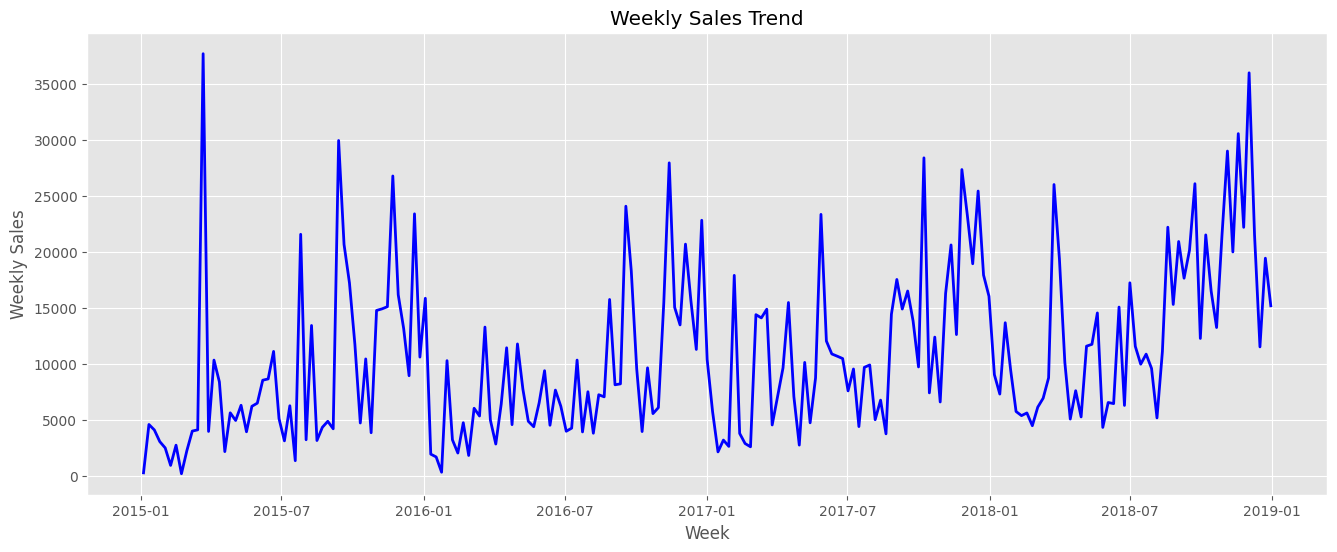

In [11]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Week"],

    weekly_sales["Weekly Sales"],

    linewidth=2,

    color="blue"

)

plt.title("Weekly Sales Trend")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.grid(True)

plt.show()

# Distribution Of Weekly Sales 

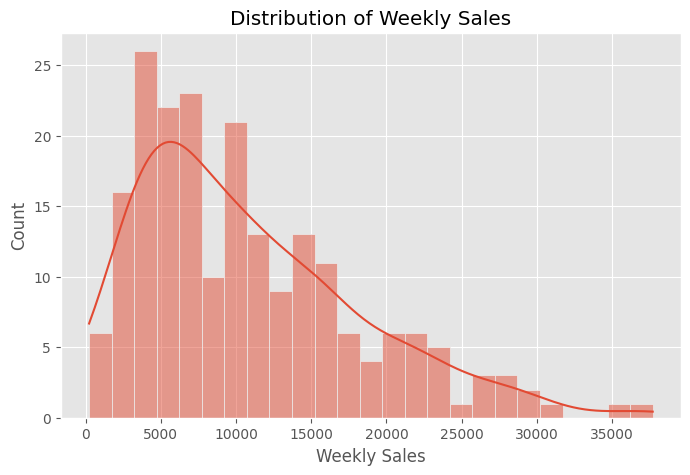

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(

    weekly_sales["Weekly Sales"],

    bins=25,

    kde=True

)

plt.title("Distribution of Weekly Sales")

plt.show()

# Weekly Sales Box Plot

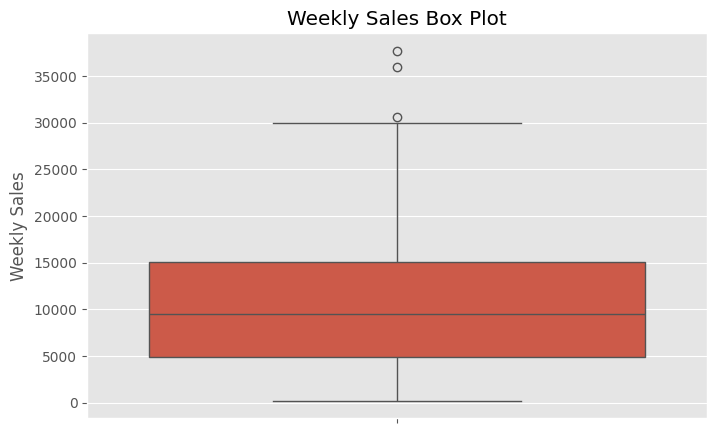

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(

    y=weekly_sales["Weekly Sales"]

)

plt.title("Weekly Sales Box Plot")

plt.show()

# Weekly Sales Describe

In [14]:
weekly_sales.describe().T

,count,mean,min,25%,50%,75%,max,std
Week,209,2017-01-01 00:00:00,2015-01-04 00:00:00,2016-01-03 00:00:00,2017-01-01 00:00:00,2017-12-31 00:00:00,2018-12-30 00:00:00,NaN
Weekly Sales,209.0,10820.750156,224.912,4905.0615,9476.086,15095.256,37703.665,7403.450316


In [15]:
weekly_sales["Week Number"] = np.arange(
    1,
    len(weekly_sales)+1
)

weekly_sales.head()

,Week,Weekly Sales,Week Number
0,2015-01-04,304.508,1
1,2015-01-11,4619.108,2
2,2015-01-18,4130.533,3
3,2015-01-25,3092.544,4
4,2015-02-01,2527.914,5


In [16]:
weekly_sales.to_csv(

    "weekly_sales.csv",

    index=False

)

print("Weekly dataset saved successfully.")

Weekly dataset saved successfully.


In [17]:
# ==========================================
# Import Isolation Forest
# ==========================================

from sklearn.ensemble import IsolationForest

# Weekly Saels Table

In [18]:
# Use only Weekly Sales for anomaly detection

X = weekly_sales[["Weekly Sales"]]

X.head()

,Weekly Sales
0,304.508
1,4619.108
2,4130.533
3,3092.544
4,2527.914


# Isolation Forest Model

In [19]:
# ==========================================
# Isolation Forest
# ==========================================

iso_model = IsolationForest(

    n_estimators=200,

    contamination=0.05,

    random_state=42

)

iso_model.fit(X)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [20]:
weekly_sales["Isolation Prediction"] = iso_model.predict(X)

weekly_sales.head()

,Week,Weekly Sales,Week Number,Isolation Prediction
0,2015-01-04,304.508,1,-1
1,2015-01-11,4619.108,2,1
2,2015-01-18,4130.533,3,1
3,2015-01-25,3092.544,4,1
4,2015-02-01,2527.914,5,1


In [21]:
weekly_sales["Isolation Label"] = weekly_sales[
    "Isolation Prediction"
].map({

    1: "Normal",

   -1: "Anomaly"

})

In [22]:
weekly_sales["Isolation Label"].value_counts()

Isolation Label
Normal     198
Anomaly     11
Name: count, dtype: int64

# Isolation Anomalies

In [23]:
isolation_anomalies = weekly_sales[
    weekly_sales["Isolation Prediction"] == -1
]

isolation_anomalies

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label
0,2015-01-04,304.508,1,-1,Anomaly
5,2015-02-08,968.534,6,-1,Anomaly
7,2015-02-22,224.912,8,-1,Anomaly
11,2015-03-22,37703.665,12,-1,Anomaly
36,2015-09-13,29959.137,37,-1,Anomaly
55,2016-01-24,358.522,56,-1,Anomaly
144,2017-10-08,28412.098,145,-1,Anomaly
154,2017-12-17,25449.800,155,-1,Anomaly
200,2018-11-04,29017.467,201,-1,Anomaly
202,2018-11-18,30572.447,203,-1,Anomaly


# Isolation Forest - Weekly Sales Anomalies

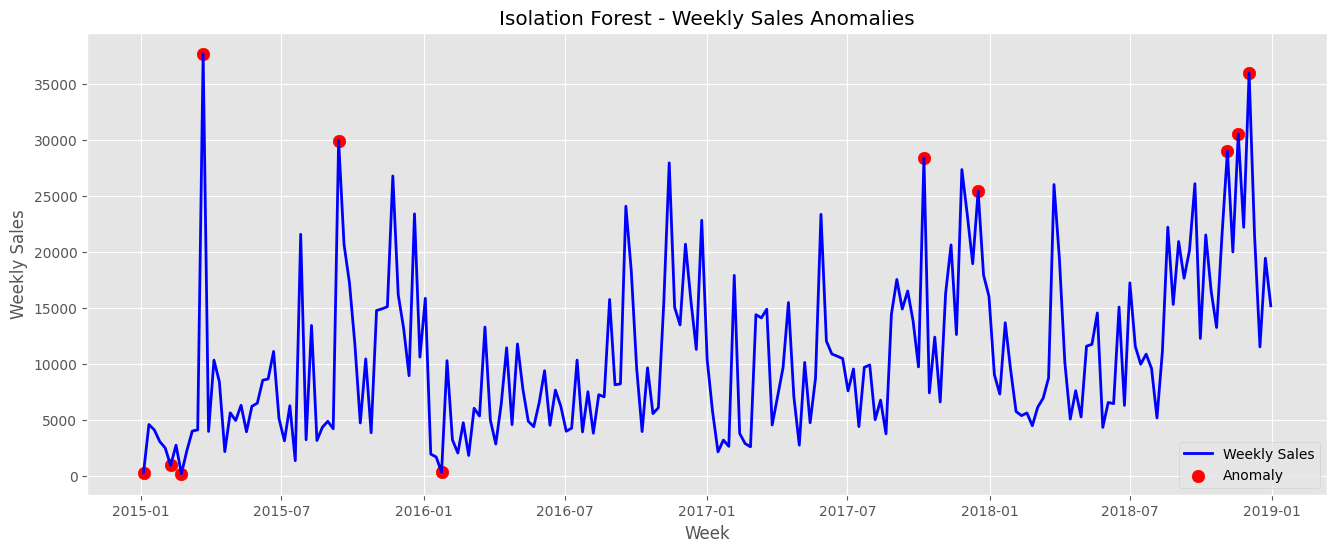

In [24]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Week"],

    weekly_sales["Weekly Sales"],

    color="blue",

    linewidth=2,

    label="Weekly Sales"

)

plt.scatter(

    isolation_anomalies["Week"],

    isolation_anomalies["Weekly Sales"],

    color="red",

    s=80,

    marker="o",

    label="Anomaly"

)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

# Detect Anomalies

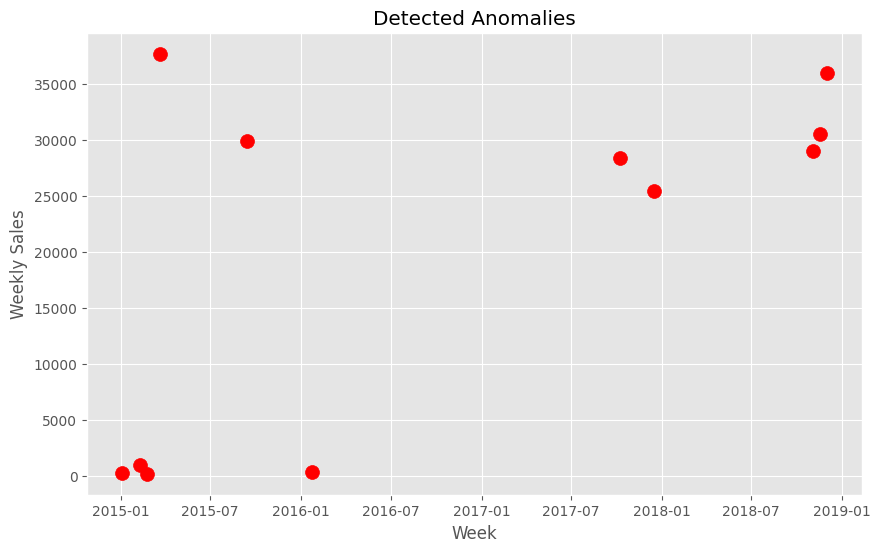

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(

    isolation_anomalies["Week"],

    isolation_anomalies["Weekly Sales"],

    color="red",

    s=100

)

plt.title("Detected Anomalies")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.grid(True)

plt.show()

# Anomaly Percentage

In [26]:
anomaly_percentage = (

    len(isolation_anomalies) /

    len(weekly_sales)

) * 100

print(f"Anomaly Percentage : {anomaly_percentage:.2f}%")

Anomaly Percentage : 5.26%


# isolation report

In [27]:
isolation_report = isolation_anomalies[

    [

        "Week",

        "Weekly Sales"

    ]

]

isolation_report.reset_index(

    drop=True,

    inplace=True

)

isolation_report

,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-02-08,968.534
2,2015-02-22,224.912
3,2015-03-22,37703.665
4,2015-09-13,29959.137
5,2016-01-24,358.522
6,2017-10-08,28412.098
7,2017-12-17,25449.800
8,2018-11-04,29017.467
9,2018-11-18,30572.447


In [28]:
weekly_sales.to_csv(

    "weekly_sales_isolation.csv",

    index=False

)

isolation_report.to_csv(

    "isolation_anomaly_report.csv",

    index=False

)

print("Isolation Forest results saved successfully.")

Isolation Forest results saved successfully.


# Summary

In [29]:
summary = pd.DataFrame({

    "Metric": [

        "Total Weeks",

        "Normal Weeks",

        "Anomalous Weeks",

        "Anomaly Percentage"

    ],

    "Value": [

        len(weekly_sales),

        len(weekly_sales) - len(isolation_anomalies),

        len(isolation_anomalies),

        round(anomaly_percentage,2)

    ]

})

summary

,Metric,Value
0,Total Weeks,209.00
1,Normal Weeks,198.00
2,Anomalous Weeks,11.00
3,Anomaly Percentage,5.26


# Rolling Mean

In [30]:
# ==========================================
# Rolling Mean (4-Week Window)
# ==========================================

weekly_sales["Rolling Mean"] = (

    weekly_sales["Weekly Sales"]

    .rolling(window=4, min_periods=1)

    .mean()

)

weekly_sales.head()

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label,Rolling Mean
0,2015-01-04,304.508,1,-1,Anomaly,304.508000
1,2015-01-11,4619.108,2,1,Normal,2461.808000
2,2015-01-18,4130.533,3,1,Normal,3018.049667
3,2015-01-25,3092.544,4,1,Normal,3036.673250
4,2015-02-01,2527.914,5,1,Normal,3592.524750


# Rolling Standard Deviation

In [31]:
# ==========================================
# Rolling Standard Deviation
# ==========================================

weekly_sales["Rolling Std"] = (

    weekly_sales["Weekly Sales"]

    .rolling(window=4, min_periods=1)

    .std()

)

weekly_sales["Rolling Std"] = weekly_sales[
    "Rolling Std"
].fillna(0)

weekly_sales.head()

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label,Rolling Mean,Rolling Std
0,2015-01-04,304.508,1,-1,Anomaly,304.508000,0.000000
1,2015-01-11,4619.108,2,1,Normal,2461.808000,3050.882918
2,2015-01-18,4130.533,3,1,Normal,3018.049667,2362.659024
3,2015-01-25,3092.544,4,1,Normal,3036.673250,1929.462566
4,2015-02-01,2527.914,5,1,Normal,3592.524750,953.362968


# Z - score calculation

In [32]:
# ==========================================
# Z-Score Calculation
# ==========================================

weekly_sales["Z-Score"] = (

    weekly_sales["Weekly Sales"]

    - weekly_sales["Rolling Mean"]

) / weekly_sales["Rolling Std"]

weekly_sales["Z-Score"] = weekly_sales[
    "Z-Score"
].replace([np.inf, -np.inf], 0)

weekly_sales["Z-Score"] = weekly_sales[
    "Z-Score"
].fillna(0)

weekly_sales.head()

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label,Rolling Mean,Rolling Std,Z-Score
0,2015-01-04,304.508,1,-1,Anomaly,304.508000,0.000000,0.000000
1,2015-01-11,4619.108,2,1,Normal,2461.808000,3050.882918,0.707107
2,2015-01-18,4130.533,3,1,Normal,3018.049667,2362.659024,0.470861
3,2015-01-25,3092.544,4,1,Normal,3036.673250,1929.462566,0.028957
4,2015-02-01,2527.914,5,1,Normal,3592.524750,953.362968,-1.116690


# Detect Z - Score Anomalies

In [33]:
# ==========================================
# Detect Z-Score Anomalies
# ==========================================

weekly_sales["Z Anomaly"] = np.where(

    np.abs(weekly_sales["Z-Score"]) > 2,

    "Anomaly",

    "Normal"

)

weekly_sales.head()

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label,Rolling Mean,Rolling Std,Z-Score,Z Anomaly
0,2015-01-04,304.508,1,-1,Anomaly,304.508000,0.000000,0.000000,Normal
1,2015-01-11,4619.108,2,1,Normal,2461.808000,3050.882918,0.707107,Normal
2,2015-01-18,4130.533,3,1,Normal,3018.049667,2362.659024,0.470861,Normal
3,2015-01-25,3092.544,4,1,Normal,3036.673250,1929.462566,0.028957,Normal
4,2015-02-01,2527.914,5,1,Normal,3592.524750,953.362968,-1.116690,Normal


In [34]:
weekly_sales["Z Anomaly"].value_counts()

Z Anomaly
Normal    209
Name: count, dtype: int64

# z score anomalies

In [35]:
zscore_anomalies = weekly_sales[

    weekly_sales["Z Anomaly"] == "Anomaly"

]

zscore_anomalies

,Week,Weekly Sales,Week Number,Isolation Prediction,Isolation Label,Rolling Mean,Rolling Std,Z-Score,Z Anomaly


# Weekly Sales - Z-Score Anomaly Detection

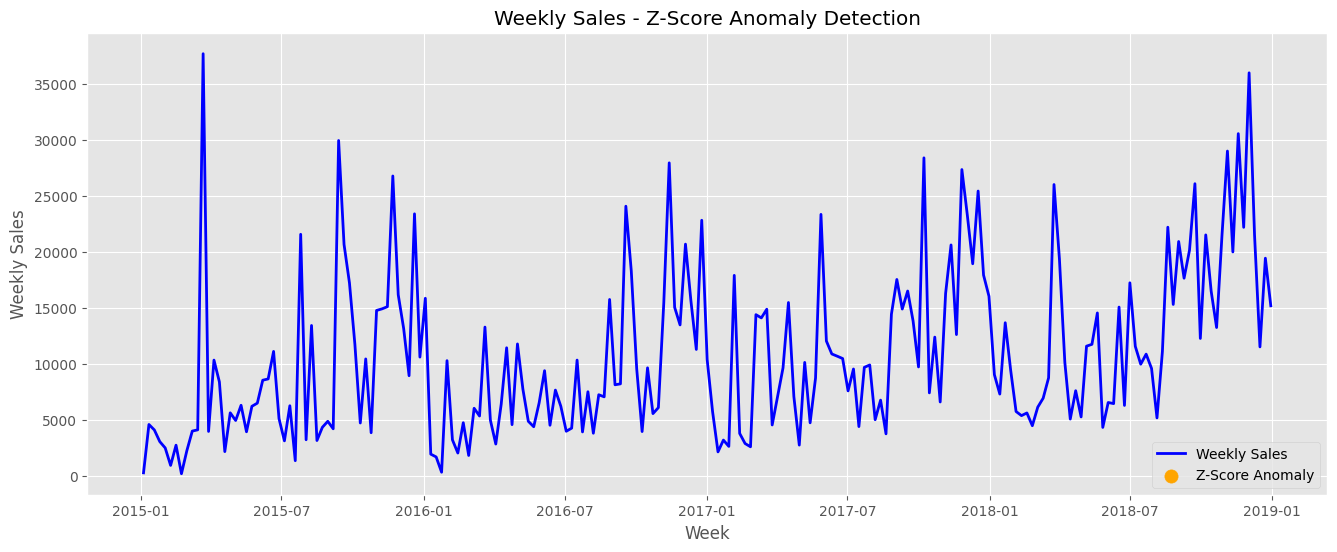

In [36]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Week"],

    weekly_sales["Weekly Sales"],

    color="blue",

    linewidth=2,

    label="Weekly Sales"

)

plt.scatter(

    zscore_anomalies["Week"],

    zscore_anomalies["Weekly Sales"],

    color="orange",

    marker="o",

    s=90,

    label="Z-Score Anomaly"

)

plt.title("Weekly Sales - Z-Score Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

# Weekly Sales with Rolling Mean

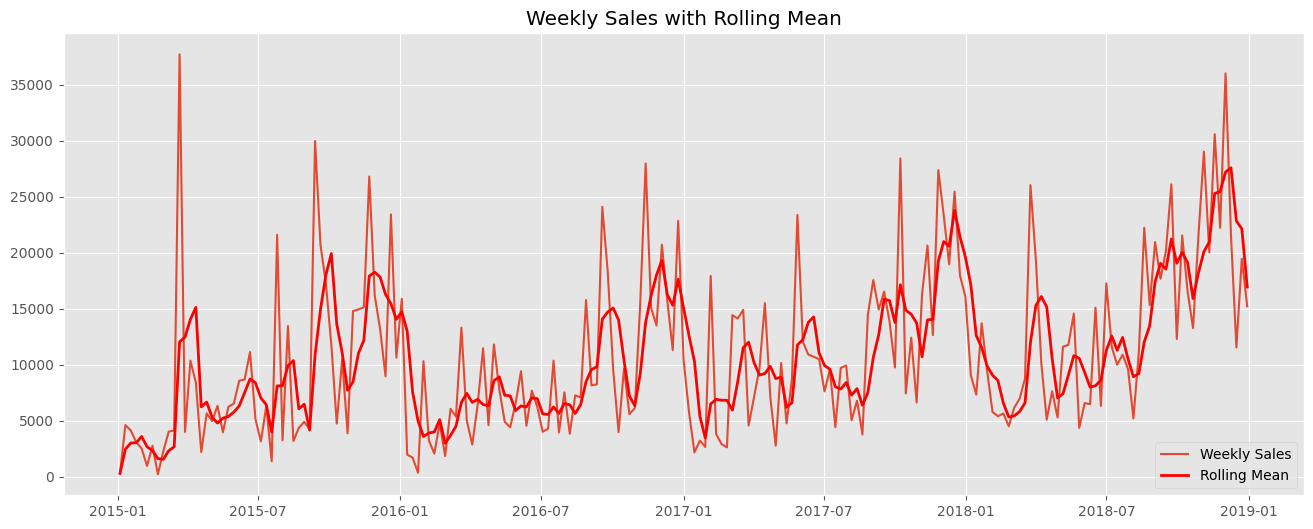

In [37]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Week"],

    weekly_sales["Weekly Sales"],

    label="Weekly Sales"

)

plt.plot(

    weekly_sales["Week"],

    weekly_sales["Rolling Mean"],

    color="red",

    linewidth=2,

    label="Rolling Mean"

)

plt.title("Weekly Sales with Rolling Mean")

plt.legend()

plt.grid(True)

plt.show()

# Distribution of z score

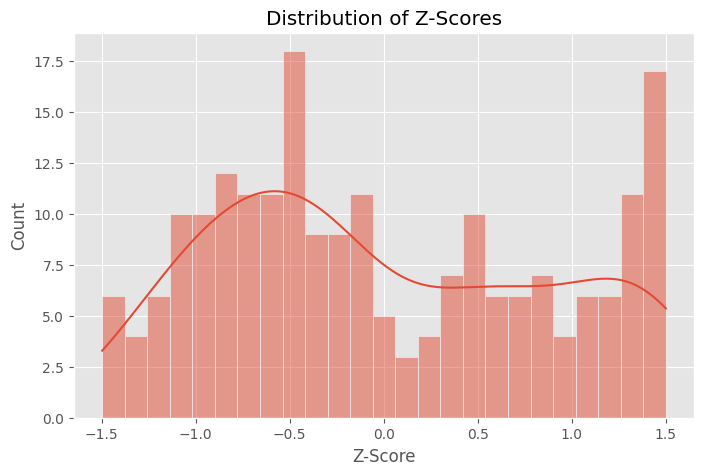

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(

    weekly_sales["Z-Score"],

    bins=25,

    kde=True

)

plt.title("Distribution of Z-Scores")

plt.show()

In [39]:
weekly_sales.to_csv(

    "weekly_sales_zscore.csv",

    index=False

)

zscore_anomalies.to_csv(

    "zscore_anomaly_report.csv",

    index=False

)

print("Z-Score anomaly report saved successfully.")

Z-Score anomaly report saved successfully.


# z score summary

In [40]:
zscore_summary = pd.DataFrame({

    "Metric":[

        "Total Weeks",

        "Normal Weeks",

        "Anomalous Weeks"

    ],

    "Value":[

        len(weekly_sales),

        len(weekly_sales)-len(zscore_anomalies),

        len(zscore_anomalies)

    ]

})

zscore_summary

,Metric,Value
0,Total Weeks,209
1,Normal Weeks,209
2,Anomalous Weeks,0


# Comparison Table

In [41]:
# ==========================================
# Compare Both Methods
# ==========================================

comparison = weekly_sales[[
    "Week",
    "Weekly Sales",
    "Isolation Label",
    "Z Anomaly"
]]

comparison.head()

,Week,Weekly Sales,Isolation Label,Z Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal


In [42]:
comparison["Agreement"] = np.where(

    (comparison["Isolation Label"] == "Anomaly") &
    (comparison["Z Anomaly"] == "Anomaly"),

    "Both Methods",

    np.where(

        (comparison["Isolation Label"] == "Anomaly") |
        (comparison["Z Anomaly"] == "Anomaly"),

        "Single Method",

        "Normal"

    )

)

comparison.head()

,Week,Weekly Sales,Isolation Label,Z Anomaly,Agreement
0,2015-01-04,304.508,Anomaly,Normal,Single Method
1,2015-01-11,4619.108,Normal,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal,Normal


# comparison value counts

In [43]:
comparison["Agreement"].value_counts()

Agreement
Normal           198
Single Method     11
Name: count, dtype: int64

# common anomalies

In [44]:
common_anomalies = comparison[
    comparison["Agreement"] == "Both Methods"
]

common_anomalies

,Week,Weekly Sales,Isolation Label,Z Anomaly,Agreement


# Common Anomalies Detected by Isolation Forest and Z-Score

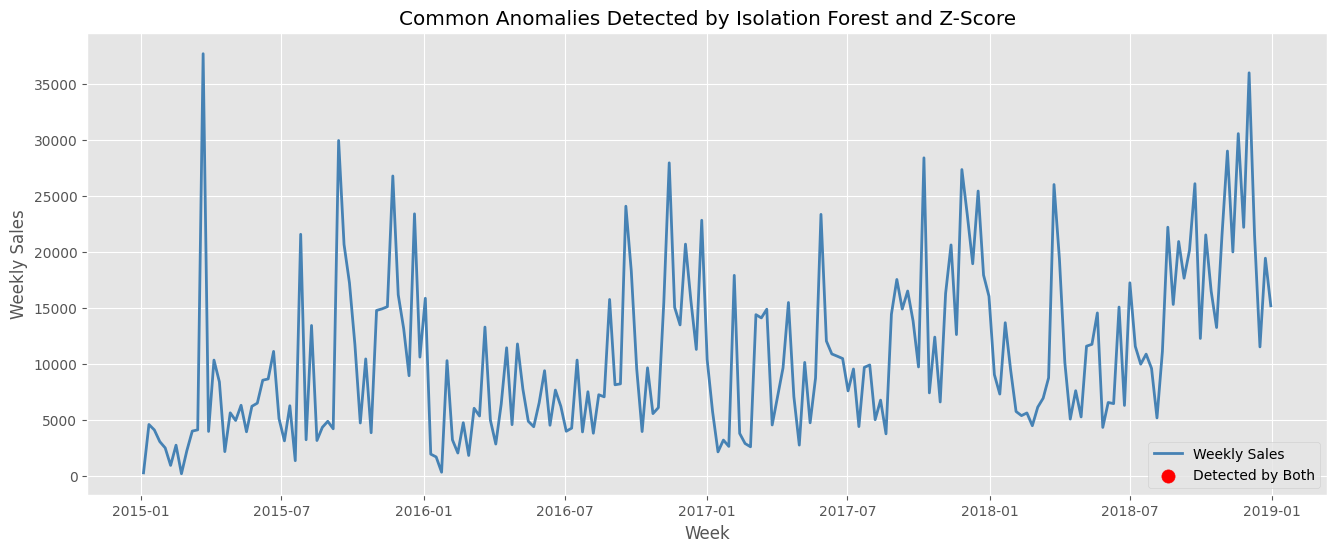

In [45]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Weekly Sales"],
    color="steelblue",
    linewidth=2,
    label="Weekly Sales"
)

plt.scatter(
    common_anomalies["Week"],
    common_anomalies["Weekly Sales"],
    color="red",
    s=90,
    marker="o",
    label="Detected by Both"
)

plt.title("Common Anomalies Detected by Isolation Forest and Z-Score")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
comparison["Possible Reason"] = "Normal"

comparison.loc[
    comparison["Agreement"] == "Both Methods",
    "Possible Reason"
] = "Possible festive sale, promotion, stock shortage or supply disruption"

comparison.loc[
    comparison["Agreement"] == "Single Method",
    "Possible Reason"
] = "Requires further business investigation"

comparison.head()

,Week,Weekly Sales,Isolation Label,Z Anomaly,Agreement,Possible Reason
0,2015-01-04,304.508,Anomaly,Normal,Single Method,Requires further business investigation
1,2015-01-11,4619.108,Normal,Normal,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal,Normal,Normal


# Final Report

In [47]:
final_report = comparison[
    comparison["Agreement"] != "Normal"
]

final_report.reset_index(
    drop=True,
    inplace=True
)

final_report

,Week,Weekly Sales,Isolation Label,Z Anomaly,Agreement,Possible Reason
0,2015-01-04,304.508,Anomaly,Normal,Single Method,Requires further business investigation
1,2015-02-08,968.534,Anomaly,Normal,Single Method,Requires further business investigation
2,2015-02-22,224.912,Anomaly,Normal,Single Method,Requires further business investigation
3,2015-03-22,37703.665,Anomaly,Normal,Single Method,Requires further business investigation
4,2015-09-13,29959.137,Anomaly,Normal,Single Method,Requires further business investigation
5,2016-01-24,358.522,Anomaly,Normal,Single Method,Requires further business investigation
6,2017-10-08,28412.098,Anomaly,Normal,Single Method,Requires further business investigation
7,2017-12-17,25449.800,Anomaly,Normal,Single Method,Requires further business investigation
8,2018-11-04,29017.467,Anomaly,Normal,Single Method,Requires further business investigation
9,2018-11-18,30572.447,Anomaly,Normal,Single Method,Requires further business investigation


In [48]:
comparison.to_csv(
    "anomaly_comparison.csv",
    index=False
)

final_report.to_csv(
    "final_anomaly_report.csv",
    index=False
)

print("Final anomaly reports saved successfully.")

Final anomaly reports saved successfully.


In [49]:
summary = pd.DataFrame({

    "Metric":[
        "Total Weeks",
        "Isolation Forest Anomalies",
        "Z-Score Anomalies",
        "Common Anomalies"
    ],

    "Value":[
        len(weekly_sales),
        len(isolation_anomalies),
        len(zscore_anomalies),
        len(common_anomalies)
    ]

})

summary

,Metric,Value
0,Total Weeks,209
1,Isolation Forest Anomalies,11
2,Z-Score Anomalies,0
3,Common Anomalies,0
